<a href="https://colab.research.google.com/github/ViddaD48/1D---CNN-model-development-for-MIT-BIH-Arrhythmia-Database-v1.0.0/blob/main/Implementing_CNN_for_single_ECG_record.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Building the model for 1 record of the dataset. (100.atr)

In this notebook I develop a 1D CNN model that takes in data from 1 ECG reading which contains more than 100 datapoints. The model is then trained to identify anomalies.

Steps


1.   Raw signal is observed
2.   R-peak locations observed
3. Hearbeat is segmented
4. The labels are cleaned
5. CNN training
6. Evaluation of the model




# Data Preprocessing

In [3]:
pip install wfdb

  Using cached wfdb-4.3.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached pandas-2.3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
Using cached wfdb-4.3.0-py3-none-any.whl (163 kB)
Using cached pandas-2.3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (12.4 MB)
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [4]:
import wfdb
import numpy as np
import pandas as pd

In [5]:
record = wfdb.rdrecord("100")
ann = wfdb.rdann("100", "atr")

signal = record.p_signal[:, 0]   # ECG channel 0
r_peaks = ann.sample
symbols = ann.symbol

In [6]:
print(signal)
print(r_peaks)
print(symbols)

[-0.145 -0.145 -0.145 ... -0.675 -0.765 -1.28 ]
[    18     77    370 ... 649484 649734 649991]
['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N'

In [7]:
label_map = {
    'N': 'Normal',
    'L': 'Normal', 'R': 'Normal',
    'V': 'Ventricular',
    'A': 'Atrial',
    'F': 'Fusion'
}

In [8]:
window_size = 180
half = window_size // 2

beats = []
labels = []

for peak, sym in zip(r_peaks, symbols):
    if sym not in label_map:
        continue

    if peak - half < 0 or peak + half >= len(signal):
        continue

    beat = signal[peak-half : peak+half]
    beats.append(beat)
    labels.append(label_map[sym])

In [9]:
X = np.array(beats)

df = pd.DataFrame(X)
df["label"] = labels

In [10]:
df

,0,1,2,3,4,5,6,7,8,9,...,171,172,173,174,175,176,177,178,179,label
0,-0.305,-0.310,-0.300,-0.305,-0.290,-0.300,-0.300,-0.305,-0.305,-0.290,...,-0.410,-0.415,-0.425,-0.420,-0.435,-0.430,-0.430,-0.420,-0.430,Normal
1,-0.330,-0.345,-0.345,-0.355,-0.350,-0.340,-0.330,-0.340,-0.340,-0.340,...,-0.415,-0.405,-0.405,-0.410,-0.415,-0.420,-0.420,-0.425,-0.415,Normal
2,-0.375,-0.385,-0.355,-0.360,-0.355,-0.360,-0.360,-0.370,-0.360,-0.345,...,-0.370,-0.375,-0.385,-0.390,-0.390,-0.375,-0.365,-0.385,-0.380,Normal
3,-0.345,-0.345,-0.350,-0.355,-0.345,-0.330,-0.330,-0.335,-0.335,-0.340,...,-0.425,-0.425,-0.425,-0.420,-0.425,-0.450,-0.445,-0.450,-0.435,Normal
4,-0.340,-0.340,-0.340,-0.325,-0.325,-0.325,-0.345,-0.350,-0.340,-0.330,...,-0.395,-0.395,-0.405,-0.410,-0.425,-0.425,-0.410,-0.410,-0.420,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2266,-0.355,-0.350,-0.330,-0.330,-0.340,-0.350,-0.360,-0.345,-0.330,-0.340,...,-0.335,-0.335,-0.335,-0.335,-0.325,-0.330,-0.310,-0.320,-0.315,Normal
2267,-0.295,-0.295,-0.285,-0.270,-0.265,-0.275,-0.290,-0.290,-0.290,-0.275,...,-0.280,-0.285,-0.285,-0.295,-0.305,-0.295,-0.280,-0.285,-0.295,Normal
2268,-0.285,-0.275,-0.280,-0.275,-0.290,-0.280,-0.285,-0.280,-0.265,-0.285,...,-0.350,-0.350,-0.365,-0.350,-0.350,-0.345,-0.340,-0.350,-0.355,Normal
2269,-0.305,-0.300,-0.305,-0.305,-0.325,-0.325,-0.330,-0.320,-0.315,-0.320,...,-0.350,-0.355,-0.370,-0.355,-0.360,-0.340,-0.340,-0.350,-0.350,Normal


In [11]:
label_to_id = {"Normal":0, "Ventricular":1, "Atrial":2, "Fusion":3}
df["label_id"] = df["label"].map(label_to_id)

In [13]:
print(len(beats))

2271


In [14]:
df.drop(columns=["label"], inplace=True)


In [15]:
df

,0,1,2,3,4,5,6,7,8,9,...,171,172,173,174,175,176,177,178,179,label_id
0,-0.305,-0.310,-0.300,-0.305,-0.290,-0.300,-0.300,-0.305,-0.305,-0.290,...,-0.410,-0.415,-0.425,-0.420,-0.435,-0.430,-0.430,-0.420,-0.430,0
1,-0.330,-0.345,-0.345,-0.355,-0.350,-0.340,-0.330,-0.340,-0.340,-0.340,...,-0.415,-0.405,-0.405,-0.410,-0.415,-0.420,-0.420,-0.425,-0.415,0
2,-0.375,-0.385,-0.355,-0.360,-0.355,-0.360,-0.360,-0.370,-0.360,-0.345,...,-0.370,-0.375,-0.385,-0.390,-0.390,-0.375,-0.365,-0.385,-0.380,0
3,-0.345,-0.345,-0.350,-0.355,-0.345,-0.330,-0.330,-0.335,-0.335,-0.340,...,-0.425,-0.425,-0.425,-0.420,-0.425,-0.450,-0.445,-0.450,-0.435,0
4,-0.340,-0.340,-0.340,-0.325,-0.325,-0.325,-0.345,-0.350,-0.340,-0.330,...,-0.395,-0.395,-0.405,-0.410,-0.425,-0.425,-0.410,-0.410,-0.420,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2266,-0.355,-0.350,-0.330,-0.330,-0.340,-0.350,-0.360,-0.345,-0.330,-0.340,...,-0.335,-0.335,-0.335,-0.335,-0.325,-0.330,-0.310,-0.320,-0.315,0
2267,-0.295,-0.295,-0.285,-0.270,-0.265,-0.275,-0.290,-0.290,-0.290,-0.275,...,-0.280,-0.285,-0.285,-0.295,-0.305,-0.295,-0.280,-0.285,-0.295,0
2268,-0.285,-0.275,-0.280,-0.275,-0.290,-0.280,-0.285,-0.280,-0.265,-0.285,...,-0.350,-0.350,-0.365,-0.350,-0.350,-0.345,-0.340,-0.350,-0.355,0
2269,-0.305,-0.300,-0.305,-0.305,-0.325,-0.325,-0.330,-0.320,-0.315,-0.320,...,-0.350,-0.355,-0.370,-0.355,-0.360,-0.340,-0.340,-0.350,-0.350,0


In [16]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

df contains segmented heartbeats extracted from a single ECG record.
Each row represents one heartbeat, and each column corresponds to a time sample within that heartbeat window.
In total, there are 2270 heartbeats, each consisting of 180 samples.

# Training the model

In [19]:
pd.Series(y).value_counts()

,count
0,2237
2,33
1,1


Since one label contains only a single heartbeat, it cannot be used to train or evaluate a CNN model reliably.
Including such a class would prevent proper data splitting and lead to invalid or misleading results.

In [20]:
y_series = pd.Series(y)

valid_classes = y_series.value_counts()[y_series.value_counts() >= 2].index
mask = y_series.isin(valid_classes)

X = X[mask]
y = y[mask]

In [21]:
pd.Series(y).value_counts()

,count
0,2237
2,33


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, stratify=y, random_state=1)

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

In [24]:
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

In [26]:
print(X_train.shape)
print(y_train_cat.shape)

(1816, 180)
(1816, 3)


In [27]:
model = Sequential()

# 1st Conv Layer
model.add(Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=(X_train.shape[1], 1)))
model.add(MaxPooling1D(pool_size=2))

# 2nd Conv Layer
model.add(Conv1D(filters=64, kernel_size=5, activation='relu'))
model.add(MaxPooling1D(pool_size=2))

# Flatten and Dense Layers
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(y_train_cat.shape[1], activation='softmax'))  # output layer


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [29]:
X_train_reshaped = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_reshaped = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [30]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(
    X_train_reshaped, y_train_cat,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.8560 - loss: 0.3526 - val_accuracy: 0.9780 - val_loss: 0.1517
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9898 - loss: 0.0954 - val_accuracy: 0.9780 - val_loss: 0.1330
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.9891 - loss: 0.0684 - val_accuracy: 0.9780 - val_loss: 0.1011
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.9900 - loss: 0.0526 - val_accuracy: 0.9780 - val_loss: 0.0825
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9891 - loss: 0.0504 - val_accuracy: 0.9808 - val_loss: 0.0709
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9903 - loss: 0.0420 - val_accuracy: 0.9808 - val_loss: 0.0734
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9908 - loss: 0.0322 - val_accuracy: 0.9808 - val_loss: 0.0686
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9892 - loss: 0.0351 - val_accuracy: 0.9808 - v

In [31]:
test_loss, test_acc = model.evaluate(X_test_reshaped, y_test_cat)
print(f'Test Accuracy: {test_acc:.4f}')

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9964 - loss: 0.0093
Test Accuracy: 0.9934


In [33]:
# Get predicted probabilities
y_pred_probs = model.predict(X_test_reshaped)

# Convert to class labels
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


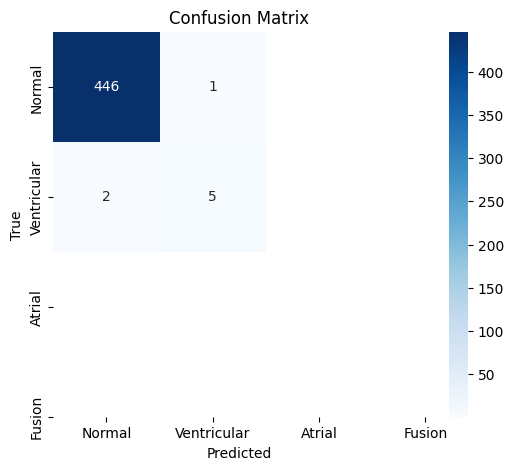

In [34]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot it
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_to_id.keys(),
            yticklabels=label_to_id.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

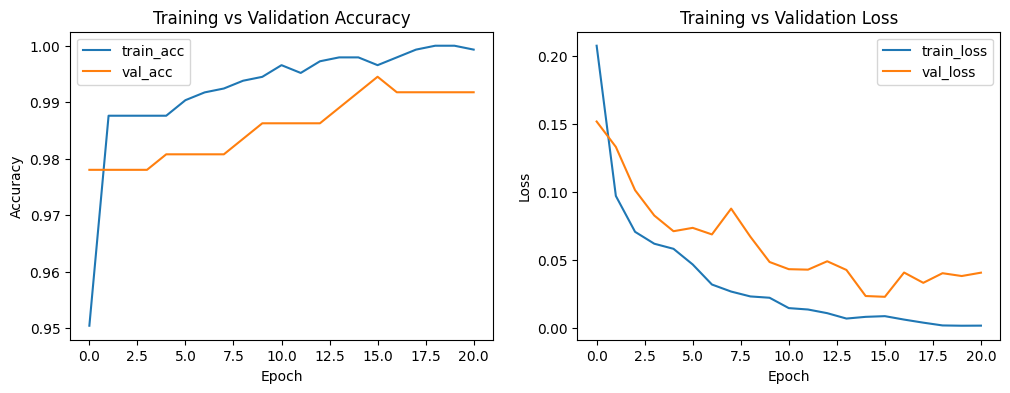

In [36]:
# Accuracy
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()
